# **Загрузка данных**

In [ ]:
# загрузка датасета MNIST

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# **Импорты библиотек**

In [ ]:
# Подключение утилит для to_categorical
from tensorflow.keras import utils

# Подключение библиотеки для работы с массивами
import numpy as np

# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt

# Подключение библиотеки для генерации случайных чисел
import random

# Подключение класса для работы с изображением
from PIL import Image

# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

# **Вывод изображений для работы**

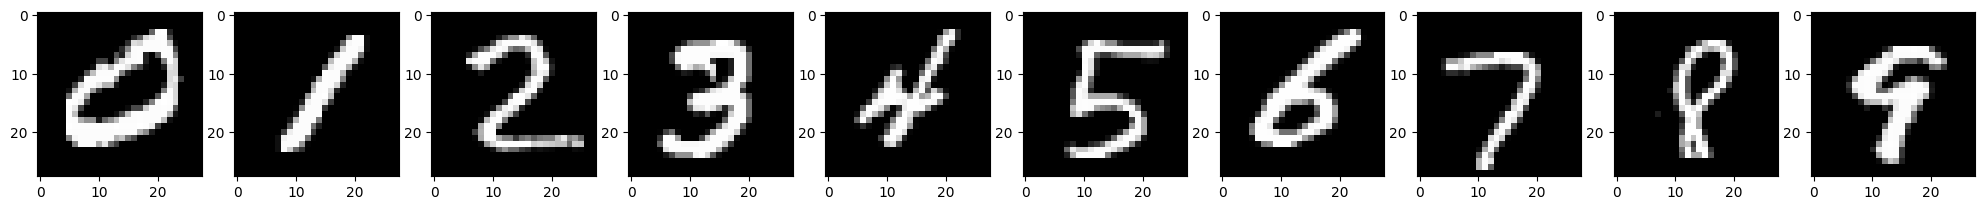

In [ ]:
# вывод изображений каждого класса для ознакомления с датасетом

fig, axs = plt.subplots(1, 10, figsize=(25,3)) # создаем полотно для 10 графиков с размером 25 на 3
for i in range(10):
  label_indexes = np.where(y_train == i)[0] # получаем список из индексов положений класса i в y_train
  index = random.choice(label_indexes) # выбирает случайный индекс из списка созданного выше
  img = x_train[index] # выбираем из x_train нужное положение
  axs[i].imshow(Image.fromarray(img), cmap='gray') # выводим изображение

plt.show()

# **Обрабатываем изображения**

In [ ]:
# добавляем размерность массиву mnist, чтобы сеть поняла что это чб
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1).astype('float32')/255
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1).astype('float32')/255

# преобразуем выборки с ответами в OHE
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

# посмотрим форматы выборок перед обучением
print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print()
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

x_train: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)

y_train: (60000, 10)
y_test: (10000, 10)


## **Создание и сборка модели**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model=models.Sequential([
    #Первый сверточный слой: ищет 32 разных простых паттерна
    layers.Conv2D(32, (3, 3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    #Второй сверточный слой: ищет 64 разных простых паттерна
    layers.Conv2D(64, (3, 3),activation='relu'),
    #Уменьшаем картинку в 2 раза (выбираем максимум из квадрата 2x2)
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])
# Компилируем оптимизатор с нужным шагом обучения и функцию потерь
opt=tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# **Обучение модели и точность на проверочной и тестовой выборках**

In [ ]:
history=model.fit(x_train,y_train,epochs=15,batch_size=128, validation_split=0.2)
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=1)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9202 - loss: 0.2761 - val_accuracy: 0.9696 - val_loss: 0.1038
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9785 - loss: 0.0712 - val_accuracy: 0.9794 - val_loss: 0.0687
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9843 - loss: 0.0504 - val_accuracy: 0.9849 - val_loss: 0.0514
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9877 - loss: 0.0391 - val_accuracy: 0.9833 - val_loss: 0.0537
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9904 - loss: 0.0313 - val_accuracy: 0.9863 - val_loss: 0.0436
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9920 - loss: 0.0258 - val_accuracy: 0.9882 - val_loss: 0.0401
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9931 - loss: 0.0210 - val_accuracy: 0.9865 - val_loss: 0.0499
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9948 - loss: 0.0167 - val_accuracy: 0.

# **Сводная информация**

In [ ]:
#Тоности обучения на разных данных
print(f"Точность на обучении: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Точность на валидационных данных: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Точность на тесте:    {test_acc*100:.2f}%")

Точность на обучении: 99.95%
Точность на валидационных данных: 99.59%
Точность на тесте:    99.19%


# **Вывод графиков обучения**

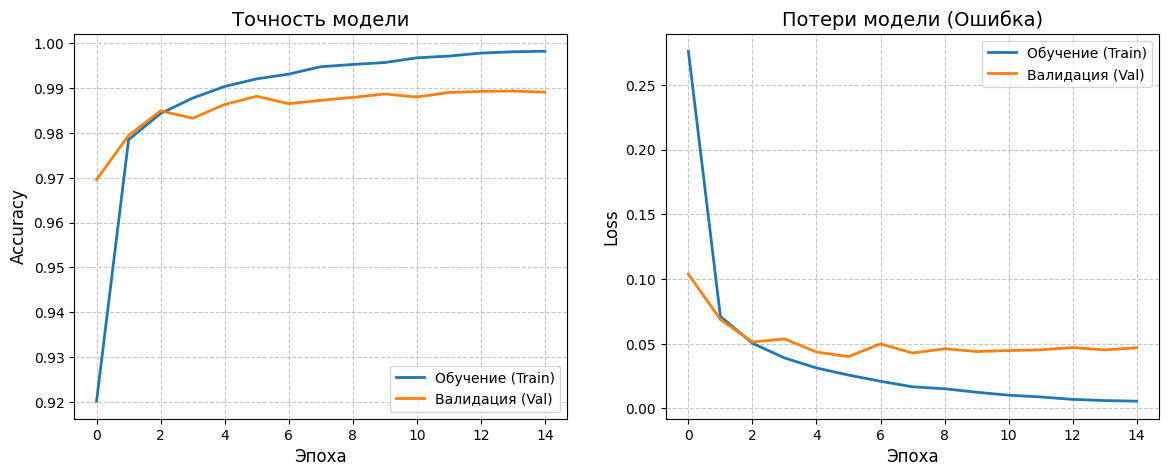

In [ ]:
plt.figure(figsize=(14, 5))

#График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучение (Train)', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Валидация (Val)', linewidth=2)
plt.title('Точность модели', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

#График потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучение (Train)', linewidth=2)
plt.plot(history.history['val_loss'], label='Валидация (Val)', linewidth=2)
plt.title('Потери модели (Ошибка)', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()